In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt

In [160]:
#%pip install -e ..

Obtaining file:///glade/u/home/qingyuany/repos/spatialtuning
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for proj2dhullsampler (pyproject.toml) ... done
  Created wheel for proj2dhullsampler: filename=proj2dhullsampler-0.1.0-0.editable-py3-none-any.whl size=3569 sha256=664026cddb0e8f72faf26e86f4d264f7204995923622fe49ef25e93d54603819
  Stored in directory: /glade/derecho/scratch/qingyuany/tmp/pip-ephem-wheel-cache-n5bupb5t/wheels/50/4e/df/9c5238c00171ab2ac4c6ca37824caa82a453cfc9707feec53b
Successfully built proj2dhullsampler
  Attempting uninstall: proj2dhullsampler
    Found existing installation: proj2dhullsampler 0.1.0
    Uninstalling proj2dhullsampler-0.1.0:
      Successfully uninstalled proj2dhullsampler-0.1.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from proj2dhullsampler import Prep_Mask_Generation
from proj2dhullsampler.prep_class import meta_one_hot_shot

In [3]:
obs = xr.open_dataset('/glade/work/fanda/miles-climatesleuth/microphysics_analysis/data/satellite_climatologies_withuncertainty360nlon180nlat_updatedMar2026.nc')
obs = obs.mean(dim = "mos").sel(obstype = 1)
obs['pr'] = obs['pr']/(1000 * 86400)

In [4]:
working_dir = '/glade/work/qingyuany/camml_re'
case_name = "v2_extreme"


obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TGCLDLWP": "tlwp", "TMQ": "pwv",
          "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}


In [5]:
ppe = xr.open_dataset("/glade/work/qingyuany/camml_re/v1_filter_extreme/post_simulation/batch_filter_v1.nc")

In [6]:
obs_interp = obs.interp(
    lat=ppe["lat"],
    lon=ppe["lon"]
)

obs_interp = obs_interp[list(obs_dict.values())]
obs_interp = obs_interp.drop_vars('obstype')

In [7]:
obs_interp

<xarray.Dataset> Size: 3MB
Dimensions:    (lat: 192, lon: 288)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Data variables:
    swcrf_toa  (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan
    lwcrf_toa  (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan
    tlwp       (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan
    pwv        (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan
    olr        (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan
    pr         (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan
    swabs_toa  (lat, lon) float64 442kB nan nan nan nan nan ... nan nan nan nan

In [8]:
para = pd.read_csv("/glade/work/qingyuany/camml_re/v1_filter_extreme/post_simulation/post_paras.csv", index_col=0)
para.shape



(99, 34)

In [9]:

obs_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v0/filtered_obs_precip_freq.csv', index_col = 0)
obs_precip_freq = obs_precip_freq.iloc[:,0]

ppe_precip_freq = pd.read_csv('/glade/work/qingyuany/camml_re/v1_filter_extreme/post_simulation/filtered_extreme_precip.csv', index_col=0)

In [10]:
lat_bins = np.arange(-75, 76, 10)  # -90 to 90 every 10 degrees

In [11]:
lab_bin_labels = np.char.add(np.char.add(lat_bins[:-1].astype(str), "to"), lat_bins[1:].astype(str))

In [12]:
man_sel_locations1 = pd.Series({"nm": "PRECT", "lat_min": 4,"lat_max": 7, "lon_min":  1, "lon_max": 359})

manul_ppe_info = pd.concat([man_sel_locations1], axis  = 1).transpose()
manul_ppe_info

,nm,lat_min,lat_max,lon_min,lon_max
0,PRECT,4,7,1,359


In [13]:
weights = np.cos(np.deg2rad(obs_interp.lat))
weights = weights / weights.mean()



ppe_global = ppe[['SWCF', 'LWCF', 'FLUT', 'FSNTOA']].weighted(weights).mean(dim = ["lat", "lon"]).to_dataframe()
obs_global = obs_interp[['swcrf_toa', 'lwcrf_toa', 'olr', 'swabs_toa']].weighted(weights).mean(dim = ["lat", "lon"]).to_array().to_series()

ppe_global.columns = ['ave_SWCF', 'ave_LWCF', 'ave_FLUT', 'ave_FSNTOA'] 
obs_global.index = ['ave_SWCF', 'ave_LWCF', 'ave_FLUT', 'ave_FSNTOA'] 

In [14]:
ppe_global = pd.concat([ppe_global, ppe_precip_freq], axis = 1)
obs_global = pd.concat([obs_global, obs_precip_freq])

In [15]:
ppe_global

,ave_SWCF,ave_LWCF,ave_FLUT,ave_FSNTOA,filter_precip099,filter_precip0999,filter_precip09999
1,-43.295470,21.078436,239.048240,246.714624,403.989582,535.976257,644.573273
2,-47.314751,26.603585,234.234020,240.301114,422.257074,566.658982,705.374580
4,-63.357140,30.645878,229.743015,226.893847,370.289579,513.082890,632.159452
5,-37.670045,14.596983,247.945606,251.724466,469.509872,634.155096,776.153400
6,-49.329027,19.506287,242.692826,239.959520,539.683805,737.177560,900.455871
...,...,...,...,...,...,...,...
96,-42.302528,16.760747,245.732094,246.417191,527.118505,723.114477,885.298341
97,-44.680967,16.824953,245.470621,242.261594,537.886144,748.402554,936.170944
98,-44.999099,22.380303,238.554964,244.662140,422.158775,567.367545,683.356080
99,-47.071516,21.669666,240.048009,242.187499,399.057521,542.132341,653.690707


In [17]:
test_case = Prep_Mask_Generation(working_dir, case_name, ppe, obs_interp, obs_dict, para, lat_bins, manul_ppe_info, added_ppe_obs=[ppe_global, obs_global])

Parameter and simulation indices match
nan variables matching between obs and simulation
Added data index matching
Zonalized and manually selected obs and ppe written as csv


In [18]:
test_case.sensitivity_emulation(n_cpus = 10)


/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

In [ ]:
test_case.mask_generation(threshold_level=2.0)
test_case.mask_generation(threshold_level=2.5)
test_case.mask_generation(threshold_level=2.5)

In [114]:
meta_table = meta_one_hot_shot(test_case.meta, test_case.data_gcm.para_nm)

In [115]:
meta_table.shape

(113, 34)

In [116]:
test_case.visualize_check('TMQ_zonal_-35to-25')

AttributeError: 'EmulatedDataStorage' object has no attribute 'tf_masks'

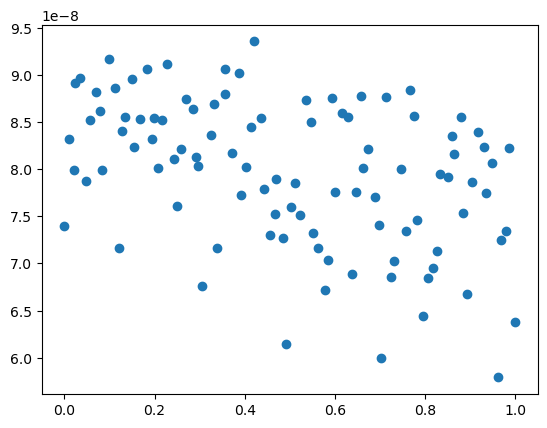

In [21]:
import matplotlib.pyplot as plt
plt.scatter(test_case.data_gcm.para_norm.micro_mg_dcs, test_case.data_gcm.ppe_pd['PRECT_zonal_5to10'])

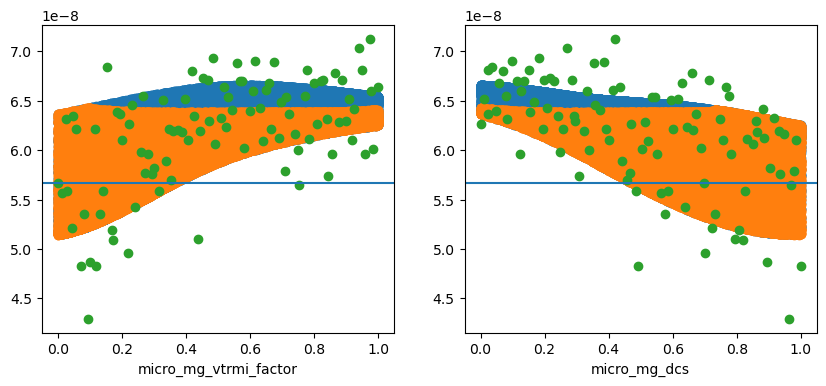

In [25]:
test_case.visualize_check('PRECT_zonal_5to15')